In [127]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.metrics import (
    calinski_harabasz_score,
    silhouette_score,
    davies_bouldin_score,
)

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN

In [128]:
DATA_PATH = Path("./data")
SPOTIFY_DATA_PATH = DATA_PATH / "spotify_songs.parquet"

In [129]:
RANDOM_STATE = 42
N_CLUSTERS = 7

In [130]:
spotify_df = pd.read_parquet(SPOTIFY_DATA_PATH)
spotify_df

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


In [131]:
spotify_df["track_album_release_date"] = pd.to_datetime(
    spotify_df["track_album_release_date"], errors="coerce"
)
spotify_df["track_album_release_year"] = spotify_df["track_album_release_date"].dt.year
spotify_df["track_album_release_month"] = spotify_df[
    "track_album_release_date"
].dt.month

In [132]:
(
    len(spotify_df.playlist_name.unique()),
    len(spotify_df.playlist_id.unique()),
    len(spotify_df.track_id.unique()),
)

(449, 471, 28356)

In [133]:
def convert_to_numerical_id(data: pd.Series) -> pd.Series:
    """
    Convert a pandas Series of IDs to numerical values.
    """
    return pd.factorize(data)[0]

In [134]:
spotify_df["playlist_id"] = convert_to_numerical_id(spotify_df["playlist_id"])
spotify_df["track_artist"] = convert_to_numerical_id(spotify_df["track_artist"])
spotify_df["track_album_id"] = convert_to_numerical_id(spotify_df["track_album_id"])

In [135]:
categorical_cols = [
    "playlist_genre",
    "playlist_subgenre",
    "track_album_release_year",
    "track_album_release_month",
]

sdf_categorized = pd.get_dummies(
    spotify_df, columns=categorical_cols, drop_first=True, dtype="int64"
)
sdf_categorized

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,danceability,...,track_album_release_month_3.0,track_album_release_month_4.0,track_album_release_month_5.0,track_album_release_month_6.0,track_album_release_month_7.0,track_album_release_month_8.0,track_album_release_month_9.0,track_album_release_month_10.0,track_album_release_month_11.0,track_album_release_month_12.0
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,0,66,0,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,0,0.748,...,0,0,0,1,0,0,0,0,0,0
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,1,67,1,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,0,0.726,...,0,0,0,0,0,0,0,0,0,1
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,2,70,2,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,0,0.675,...,0,0,0,0,1,0,0,0,0,0
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,3,60,3,Call You Mine - The Remixes,2019-07-19,Pop Remix,0,0.718,...,0,0,0,0,1,0,0,0,0,0
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,4,69,4,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,0,0.650,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,183,42,22540,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,470,0.428,...,0,1,0,0,0,0,0,0,0,0
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,10690,20,22541,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,470,0.522,...,1,0,0,0,0,0,0,0,0,0
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,9770,14,22542,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,470,0.529,...,0,1,0,0,0,0,0,0,0,0
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,10691,15,22543,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,470,0.626,...,0,0,0,0,0,0,0,0,0,0


In [136]:
drop_cols = [
    "track_id",
    "playlist_id",
    "playlist_name",
    "track_name",
    "track_album_name",
    "track_album_release_date",
]

X = sdf_categorized.drop(columns=drop_cols, errors="ignore")
X

,track_artist,track_popularity,track_album_id,danceability,energy,key,loudness,mode,speechiness,acousticness,...,track_album_release_month_3.0,track_album_release_month_4.0,track_album_release_month_5.0,track_album_release_month_6.0,track_album_release_month_7.0,track_album_release_month_8.0,track_album_release_month_9.0,track_album_release_month_10.0,track_album_release_month_11.0,track_album_release_month_12.0
0,0,66,0,0.748,0.916,6,-2.634,1,0.0583,0.102000,...,0,0,0,1,0,0,0,0,0,0
1,1,67,1,0.726,0.815,11,-4.969,1,0.0373,0.072400,...,0,0,0,0,0,0,0,0,0,1
2,2,70,2,0.675,0.931,1,-3.432,0,0.0742,0.079400,...,0,0,0,0,1,0,0,0,0,0
3,3,60,3,0.718,0.930,7,-3.778,1,0.1020,0.028700,...,0,0,0,0,1,0,0,0,0,0
4,4,69,4,0.650,0.833,1,-4.672,1,0.0359,0.080300,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,183,42,22540,0.428,0.922,2,-1.814,1,0.0936,0.076600,...,0,1,0,0,0,0,0,0,0,0
32829,10690,20,22541,0.522,0.786,0,-4.462,1,0.0420,0.001710,...,1,0,0,0,0,0,0,0,0,0
32830,9770,14,22542,0.529,0.821,6,-4.899,0,0.0481,0.108000,...,0,1,0,0,0,0,0,0,0,0
32831,10691,15,22543,0.626,0.888,2,-3.361,1,0.1090,0.007920,...,0,0,0,0,0,0,0,0,0,0


In [137]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-means

### Looking for better k value using k_elbow

In [138]:
def k_elbow_visualizer(X, k_range=(4, 12), random_state=RANDOM_STATE):
    """
    Generates the elbow method graph for KMeans.

    Parameters:
        - X: input data (already pre-processed)
        - k_range: tuple (start, end) of the number of clusters to test
        - random_state: random seed for reproducibility
    """
    inertias = []
    ks = range(k_range[0], k_range[1] + 1)

    for k in ks:
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(ks, inertias, marker="o")
    plt.title("Método do Cotovelo (Elbow Method)")
    plt.xlabel("Número de Clusters (k)")
    plt.ylabel("Inércia")
    plt.xticks(ks)
    plt.grid(True)
    plt.show()

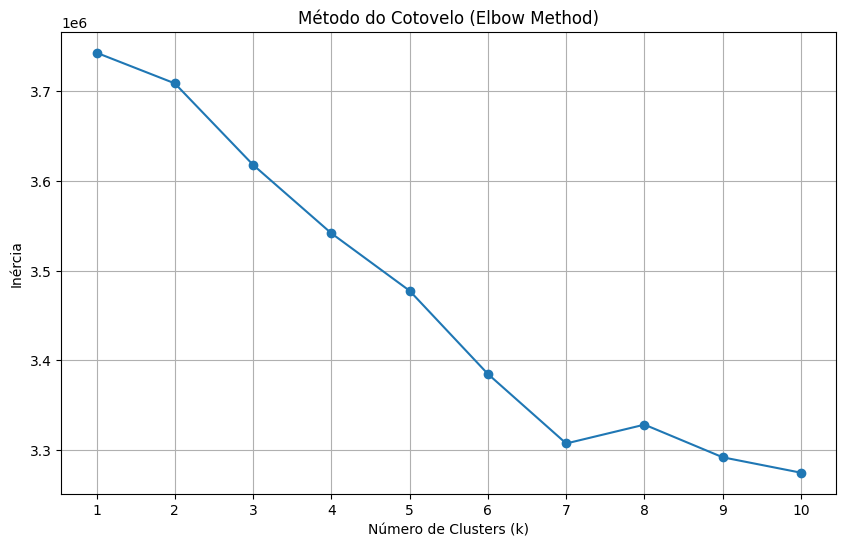

In [139]:
k_elbow_visualizer(X_scaled, k_range=(1, 10), random_state=RANDOM_STATE)

### Looking for better k value using  

In [140]:
def k_silhouette_visualizer(X, k_range=(2, 10), random_state=42):
    """
    Generates a Silhouette Score graph for KMeans clustering.

    Parameters:
        - X: input data (already pre-processed)
        - k_range: tuple (start, end) of the number of clusters to test
        - random_state: random seed for reproducibility
    """
    silhouette_scores = []
    ks = range(k_range[0], k_range[1] + 1)

    for k in ks:
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

    plt.figure(figsize=(10, 6))
    plt.plot(ks, silhouette_scores, marker="o", color="green")
    plt.title("Método da Silhueta (Silhouette Score)")
    plt.xlabel("Número de Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.xticks(ks)
    plt.grid(True)
    plt.show()

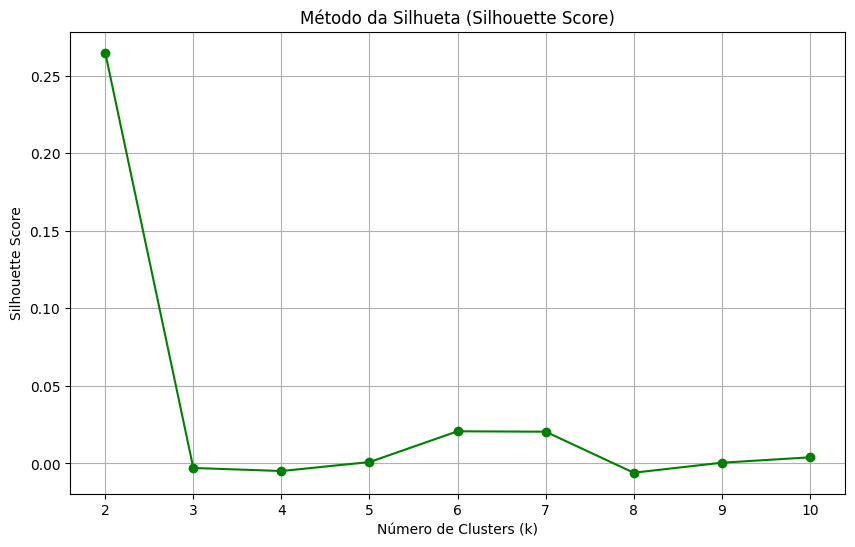

In [141]:
scores = k_silhouette_visualizer(X_scaled, k_range=(2, 10), random_state=RANDOM_STATE)

### K-Means Clustering Evaluation with Internal Validation Metrics
The elbow graph shows the end of the fall with a shoulder after k = 7. The silhouette graph, despite showing a high value for k = 2, also shows an apparent growth for the values ​​k = 6 and k = 7. For this reason we will try k = 7 for the other analyses.

In [142]:
N_CLUSTERS = 7

In [143]:
def evaluate_kmeans_metrics(X, k_value=N_CLUSTERS, random_state=RANDOM_STATE):
    """
    Compute Silhouette, Davies-Bouldin, and Calinski-Harabasz scores for K-Means
    for a fixed k value.

    Returns a DataFrame with metrics as rows and k_value as the single column.
    """
    labels = KMeans(n_clusters=k_value, random_state=random_state).fit_predict(X)
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    data = {"Silhouette": sil, "Davies-Bouldin": db, "Calinski-Harabasz": ch}

    df = pd.DataFrame(data, index=[k_value]).T
    df.columns = [f"k={k_value}"]
    return df

In [144]:
metrics_df = evaluate_kmeans_metrics(
    X_scaled, k_value=N_CLUSTERS, random_state=RANDOM_STATE
)
metrics_df

,k=7
Silhouette,0.020439
Davies-Bouldin,3.464501
Calinski-Harabasz,720.696898


### 2‑D Visualization of Clustering Results with PCA & t‑SNE

In [145]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_scaled)

In [146]:
def compute_pca_2d(X, random_state=42):
    """
    Reduce data to 2 dimensions with PCA.
    """
    return PCA(n_components=2, random_state=random_state).fit_transform(X)

In [147]:
pca_coords = compute_pca_2d(X_scaled, random_state=RANDOM_STATE)

In [148]:
def compute_tsne_2d(
    X, perplexity=30, max_iter=1000, learning_rate="auto", random_state=42
):
    """
    Reduce data to 2 dimensions with t‑SNE.
    """
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        max_iter=max_iter,
        learning_rate=learning_rate,
        random_state=random_state,
        init="pca",
    )
    return tsne.fit_transform(X)

In [149]:
tsne_coords = compute_tsne_2d(X_scaled, perplexity=40, random_state=RANDOM_STATE)

In [150]:
def plot_embedding_2d(embedding, labels, title="2‑D Cluster Visualization"):
    """
    Scatter‑plot a 2‑D embedding coloured by cluster labels.
    """
    plt.figure(figsize=(7, 6))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="tab10",
        s=15,
        alpha=0.8,
        edgecolors="none",
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

Ploting PCA:

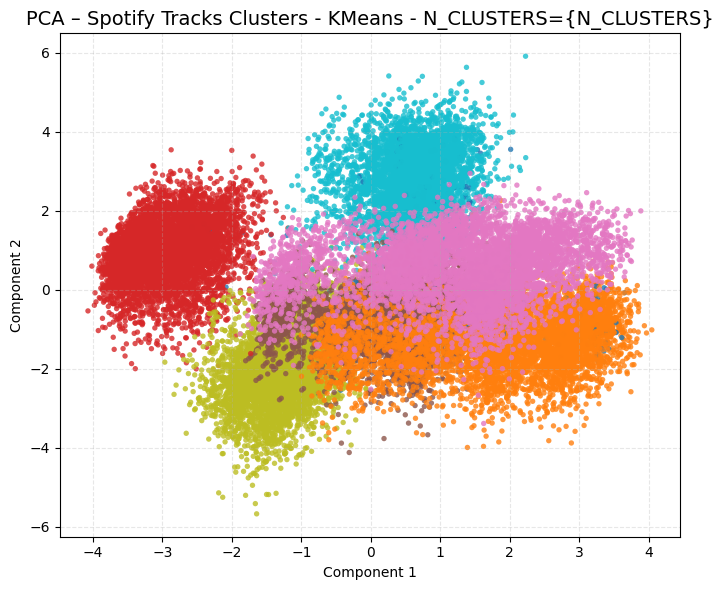

In [151]:
plot_embedding_2d(
    pca_coords,
    cluster_labels,
    title="PCA – Spotify Tracks Clusters - KMeans - N_CLUSTERS={N_CLUSTERS}",
)

Ploting TSNE:

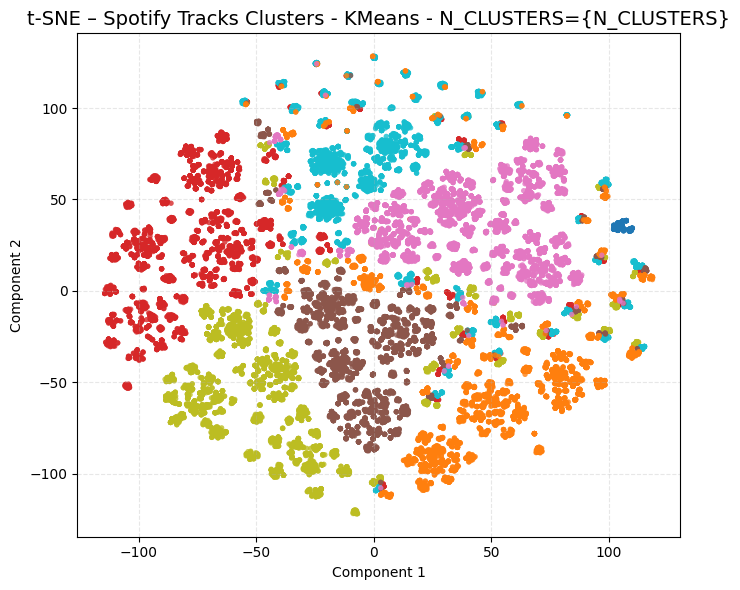

In [152]:
plot_embedding_2d(
    tsne_coords,
    cluster_labels,
    title="t‑SNE – Spotify Tracks Clusters - KMeans - N_CLUSTERS={N_CLUSTERS}",
)

## DBSCAN - Francisco Paulino Arruda Filho

In [153]:
dbscan = DBSCAN(eps=0.8, min_samples=3).fit(X_scaled)

In [154]:
def evaluate_dbscan(X, model):
    labels = model.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters < 2:
        return {
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette_score": None,
            "calinski_harabasz_score": None,
            "davies_bouldin_score": None,
        }

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette_score": silhouette_score(X, labels),
        "calinski_harabasz_score": calinski_harabasz_score(X, labels),
        "davies_bouldin_score": davies_bouldin_score(X, labels),
    }

In [155]:
from itertools import product

eps_values = [0.3, 0.5, 0.8, 1.0, 1.5]
min_samples_values = [2, 3, 4, 5, 6]

results = []
for eps, min_samples in product(eps_values, min_samples_values):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    metrics = evaluate_dbscan(X_scaled, dbscan)
    metrics.update({"eps": eps, "min_samples": min_samples})
    results.append(metrics)

df_results = pd.DataFrame(results)

In [156]:
df_results

,n_clusters,n_noise,silhouette_score,calinski_harabasz_score,davies_bouldin_score,eps,min_samples
0,67,32698,-0.345415,2.721079,0.988879,0.3,2
1,1,32830,NaN,NaN,NaN,0.3,3
2,0,32833,NaN,NaN,NaN,0.3,4
3,0,32833,NaN,NaN,NaN,0.3,5
4,0,32833,NaN,NaN,NaN,0.3,6
5,110,32612,-0.390785,2.836943,0.979463,0.5,2
6,1,32830,NaN,NaN,NaN,0.5,3
7,0,32833,NaN,NaN,NaN,0.5,4
8,0,32833,NaN,NaN,NaN,0.5,5
9,0,32833,NaN,NaN,NaN,0.5,6


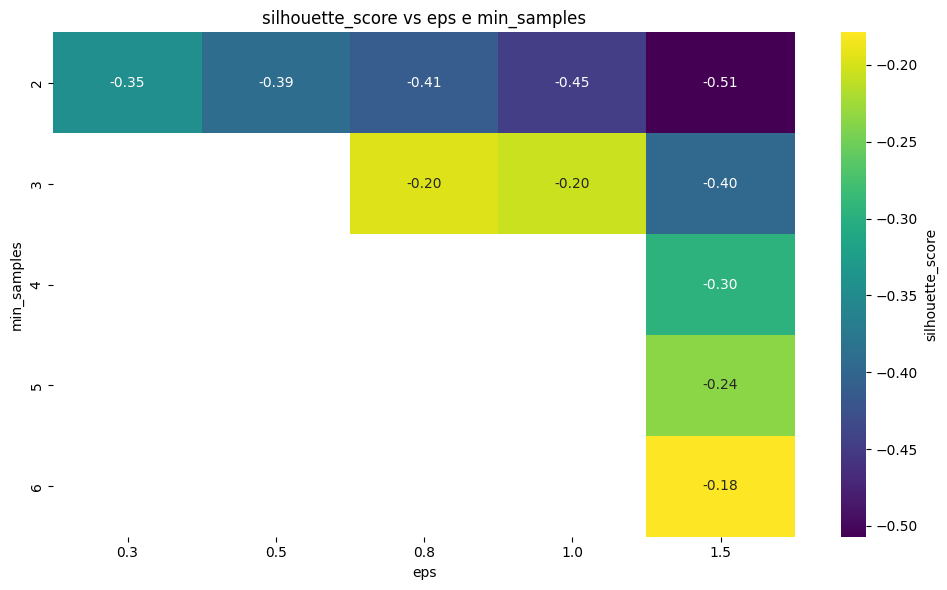

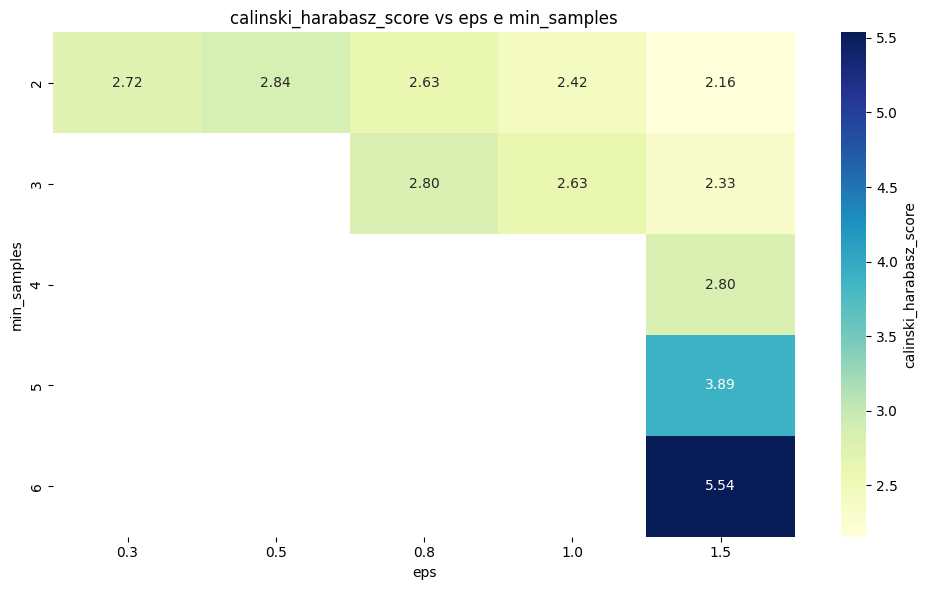

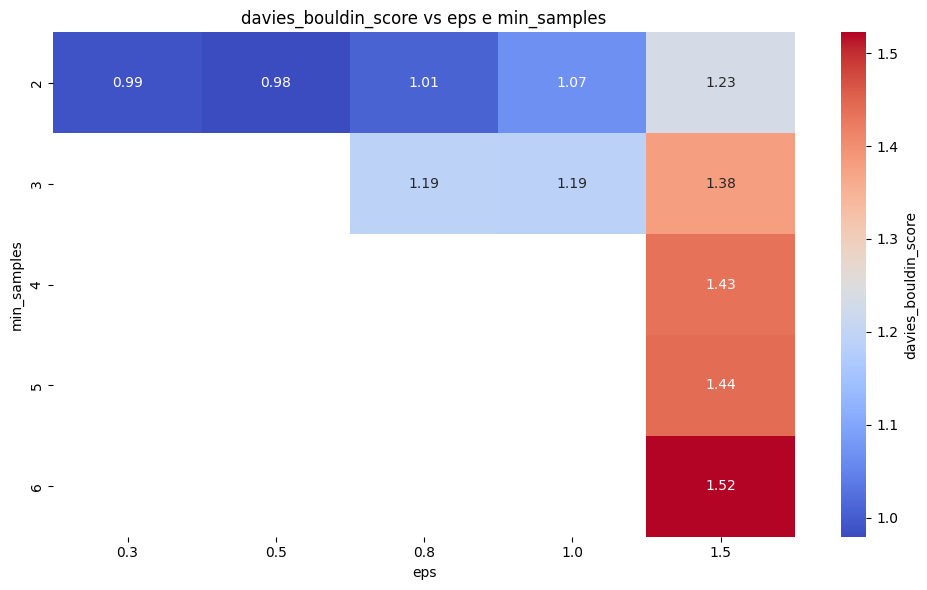

In [157]:
import seaborn as sns

# Remover linhas com None (métricas inválidas)
df_plot = df_results.dropna(
    subset=["silhouette_score", "calinski_harabasz_score", "davies_bouldin_score"]
)


# Função para criar o heatmap
def plot_heatmap(metric_name, cmap="viridis"):
    pivot = df_plot.pivot(index="min_samples", columns="eps", values=metric_name)
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap=cmap, cbar_kws={"label": metric_name}
    )
    plt.title(f"{metric_name} vs eps e min_samples")
    plt.xlabel("eps")
    plt.ylabel("min_samples")
    plt.tight_layout()
    plt.show()


# Plot de cada métrica
plot_heatmap("silhouette_score")
plot_heatmap("calinski_harabasz_score", cmap="YlGnBu")
plot_heatmap("davies_bouldin_score", cmap="coolwarm")

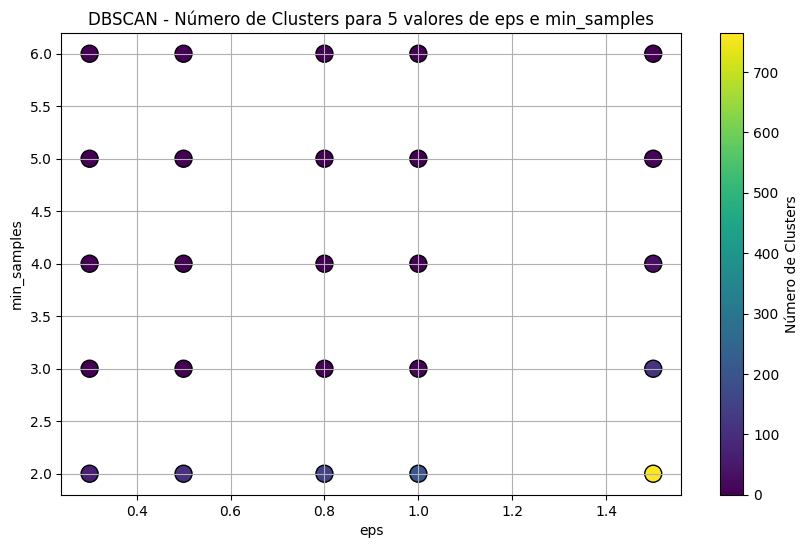

In [158]:
# Gráfico: eps vs min_samples, cor representa número de clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_results["eps"],
    df_results["min_samples"],
    c=df_results["n_clusters"],
    cmap="viridis",
    s=150,
    edgecolor="black",
)
plt.colorbar(scatter, label="Número de Clusters")
plt.xlabel("eps")
plt.ylabel("min_samples")
plt.title("DBSCAN - Número de Clusters para 5 valores de eps e min_samples")
plt.grid(True)
plt.show()

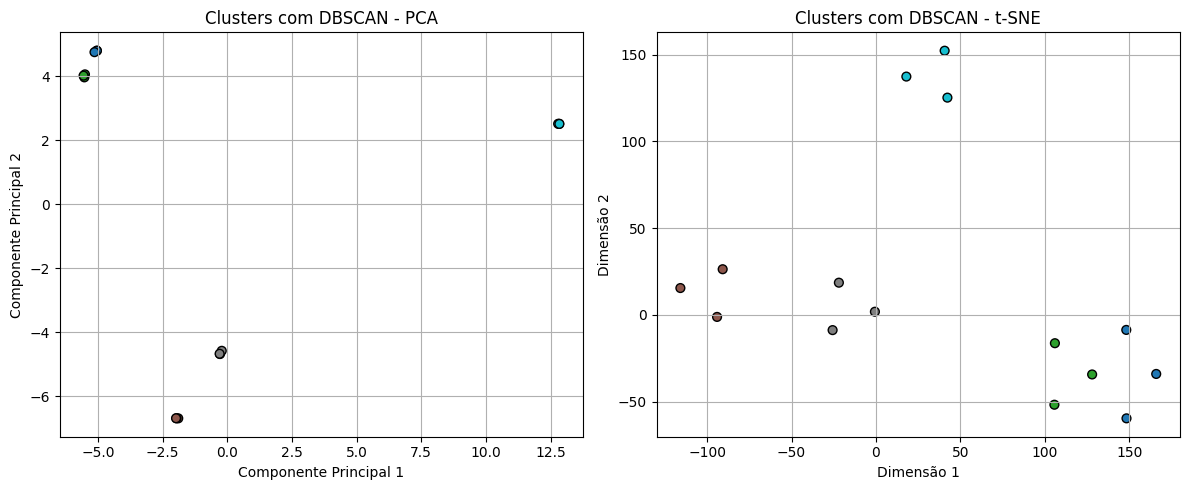

In [159]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

dbscan = DBSCAN(eps=0.8, min_samples=3).fit(X_scaled)
labels = dbscan.labels_

X_filtered = X_scaled[labels != -1]
labels_filtered = labels[labels != -1]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_filtered)

tsne = TSNE(n_components=2, perplexity=5, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_filtered)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=labels_filtered, cmap="tab10", s=40, edgecolor="k"
)
plt.title("Clusters com DBSCAN - PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)

# 🎨 Visualização t-SNE
plt.subplot(1, 2, 2)
plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1], c=labels_filtered, cmap="tab10", s=40, edgecolor="k"
)
plt.title("Clusters com DBSCAN - t-SNE")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.grid(True)

plt.tight_layout()
plt.show()

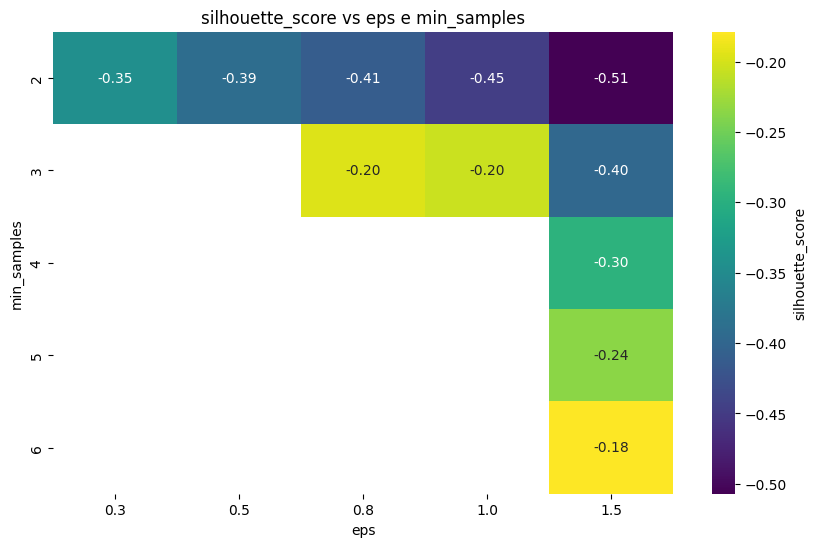

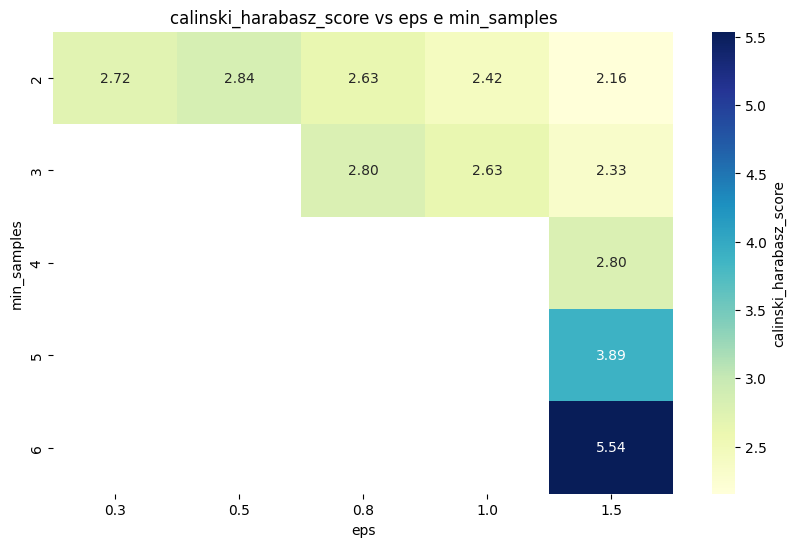

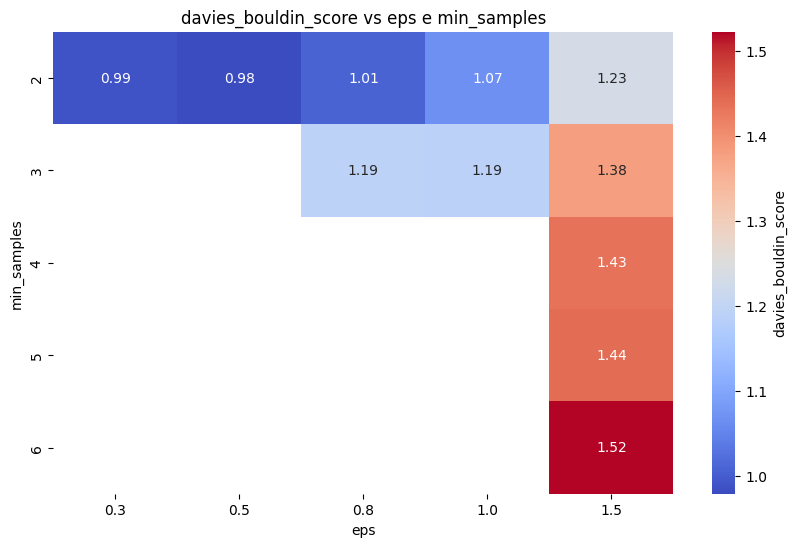

In [160]:
import seaborn as sns

# ⚠️ Remover linhas com métricas nulas (ex: apenas 1 cluster)
df_plot = df_results.dropna(
    subset=["silhouette_score", "calinski_harabasz_score", "davies_bouldin_score"]
)


# Função para criar heatmaps
def plot_heatmap(metric_name, cmap="viridis"):
    pivot = df_plot.pivot(index="min_samples", columns="eps", values=metric_name)
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap=cmap, cbar_kws={"label": metric_name}
    )
    plt.title(f"{metric_name} vs eps e min_samples")
    plt.xlabel("eps")
    plt.ylabel("min_samples")
    plt.show()


# 📊 Heatmaps das 3 métricas
plot_heatmap("silhouette_score")
plot_heatmap("calinski_harabasz_score", cmap="YlGnBu")
plot_heatmap("davies_bouldin_score", cmap="coolwarm")

## Hierarchical Clustering

### Looking for best k-value using 
### Hierarchical Clustering with Ward Linkage and Euclidean Distance

For our hierarchical clustering, we use the **Ward linkage method** combined with **Euclidean distance**. Here's why:

- **Ward linkage** minimizes the total within-cluster variance. At each step, it merges the pair of clusters that leads to the minimum increase in total within-cluster variance. This tends to create clusters that are compact and spherical, similar to k-means assumptions, and often produces more balanced clusters.
- **Euclidean distance** is the standard distance metric measuring the straight-line distance between points in the feature space. It works well with Ward linkage, as Ward's method relies on variance calculations based on Euclidean distances.

#### Finding the best number of clusters from the dendrogram

The dendrogram visually represents the hierarchical merging of samples/clusters. To choose the best number of clusters **k**:

- Look for the **largest vertical distance (gap)** between horizontal lines that do not cross any other horizontal lines (these represent cluster merges).
- Cutting the dendrogram at this large gap (horizontal line) will separate the data into clusters that are more dissimilar from each other, indicating better separation.
- In other words, the largest vertical jumps indicate natural cluster boundaries.

By selecting k corresponding to this largest vertical gap, we hope to identify the most meaningful cluster division of the data.

---

We will plot the dendrogram using this method and inspect it to decide the optimal k before quantitatively validating cluster quality with internal metrics like Silhouette score.


In [161]:
def plot_dendrogram(X, method="ward", metric="euclidean", truncate_mode=None, p=12):
    """
    Compute and plot the hierarchical clustering dendrogram.
    """
    Z = linkage(X, method=method, metric=metric)

    plt.figure(figsize=(15, 6))
    dendrogram(
        Z,
        truncate_mode=truncate_mode,
        p=p,
        leaf_rotation=90.0,
        leaf_font_size=10.0,
        show_contracted=True,
        color_threshold=None,
    )
    plt.title(f"Hierarchical Clustering Dendrogram ({method} linkage)")
    plt.xlabel("Sample index or cluster size")
    plt.ylabel("Distance")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return Z

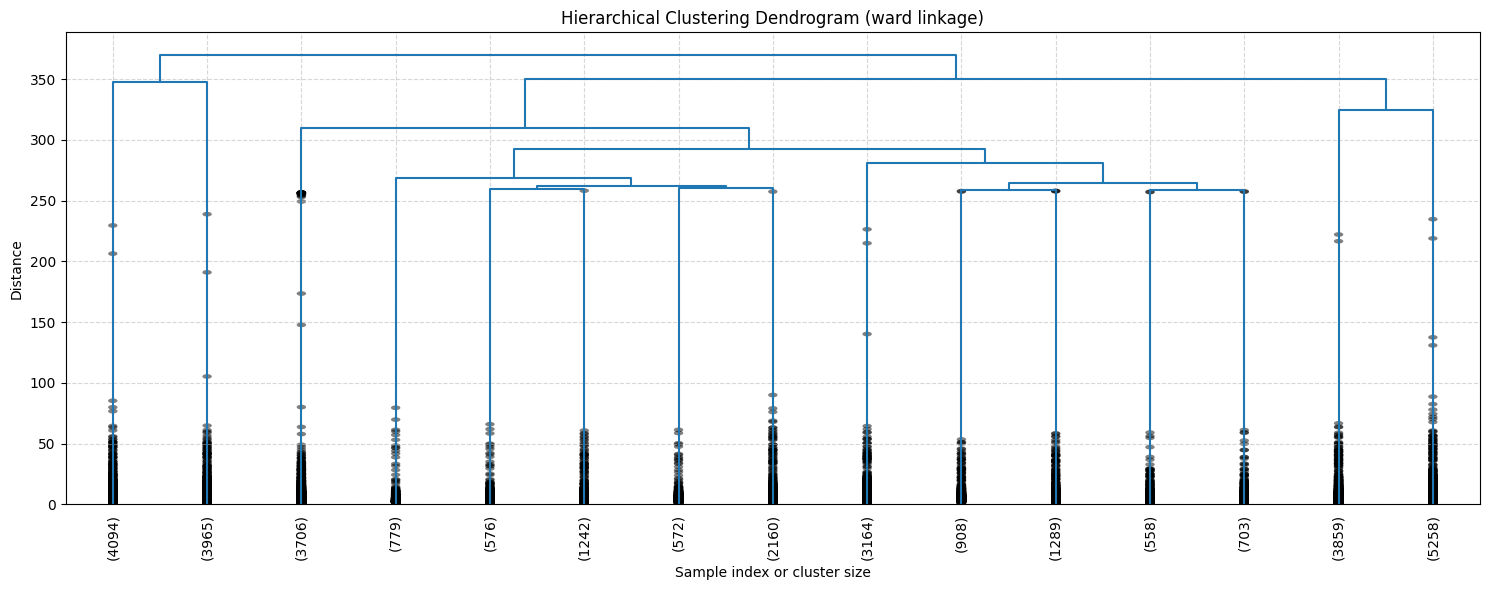

In [162]:
Z = plot_dendrogram(X_scaled, method="ward", truncate_mode="lastp", p=15)

Based on the hierarchical clustering dendrogram, I would choose $ k = 5 $ as the optimal number of clusters. This selection is justified by the presence of significant jumps in the distance levels around the 200-250 range, where the dendrogram branches start to merge into larger clusters. These jumps suggest natural groupings, and selecting $ k = 5 $ corresponds to cutting the dendrogram at a level that balances the number of clusters with the similarity within each group, avoiding overly broad or fragmented clusters.

In [163]:
N_CLUSTERS = 5

### Hierarchical Clustering Evaluation with Internal Validation Metrics

In [164]:
def get_hierarchical_labels(Z, n_clusters):
    """
    Extract flat cluster labels from linkage matrix by cutting the dendrogram.
    """

    labels = fcluster(Z, t=n_clusters, criterion="maxclust")
    return labels

In [165]:
hier_labels = get_hierarchical_labels(Z, n_clusters=N_CLUSTERS)

In [166]:
def evaluate_hierarchical_metrics(X, k_value, labels):
    """
    Calculate Silhouette, Davies-Bouldin, and Calinski-Harabasz scores for clustering labels.
    """
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    data = {
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch,
    }

    df = pd.DataFrame(data, index=[k_value]).T
    df.columns = [f"k={k_value}"]
    return df

In [167]:
hca_metrics_df = evaluate_hierarchical_metrics(
    X_scaled, k_value=N_CLUSTERS, labels=hier_labels
)
hca_metrics_df

,k=5
Silhouette,-0.026459
Davies-Bouldin,4.535616
Calinski-Harabasz,568.909831


### Visualizing Hierarchical Clustering in 2D (PCA and t-SNE)

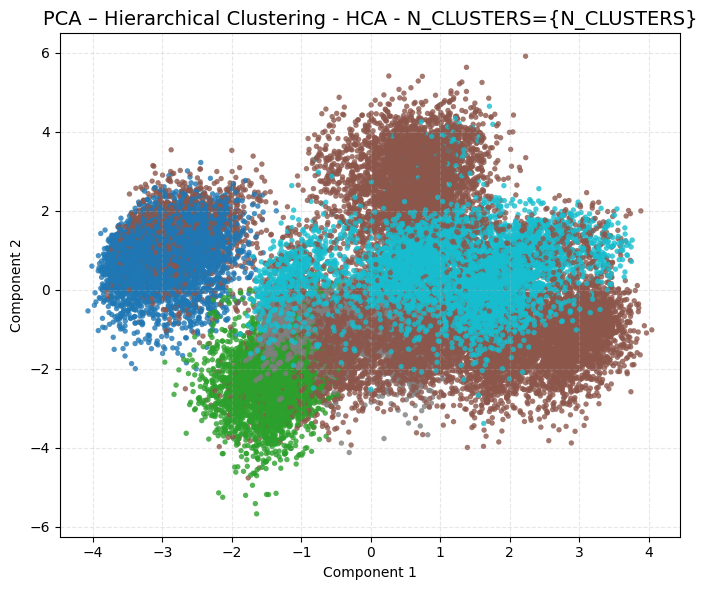

In [168]:
plot_embedding_2d(
    pca_coords,
    hier_labels,
    title="PCA – Hierarchical Clustering - HCA - N_CLUSTERS={N_CLUSTERS}",
)

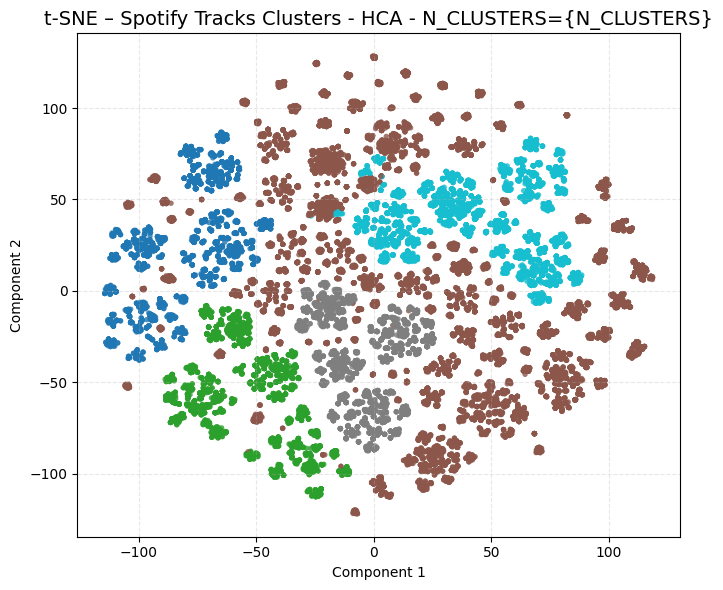

In [169]:
plot_embedding_2d(
    tsne_coords,
    hier_labels,
    title="t‑SNE – Spotify Tracks Clusters - HCA - N_CLUSTERS={N_CLUSTERS}",
)